In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import math
import pandas as pd
import bisect
import uuid

In [2]:
import requests
import urllib
import json

def get_elevation_usgs(lon_deg, lat_deg):
    url = r'https://epqs.nationalmap.gov/v1/json?'
    params = {
        'output': 'json',
        'x': lon_deg,
        'y': lat_deg,
        'units': 'Meters'
    }
    result = requests.get((url + urllib.parse.urlencode(params)))
    return float(result.json()['value'])


def get_elevation_from_open_elevation(longitude_deg, latitude_deg):
    """
    Retrieves elevation data from the Open-Elevation API for a given
    latitude and longitude.

    Args:
        latitude (float): The latitude of the location.
        longitude (float): The longitude of the location.

    Returns:
        float or None: The elevation in meters if successful, otherwise None.
    """
    url = "https://api.open-elevation.com/api/v1/lookup"
    params = {
        "locations": f"{latitude_deg},{longitude_deg}"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)
        data = response.json()
        
        if data and "results" in data and len(data["results"]) > 0:
            return data["results"][0]["elevation"]
        else:
            print("No elevation data found in the response.")
            return None
    except requests.exceptions.RequestException as e:
        print(f"Error making request to Open-Elevation API: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON response: {e}")
        return None

# # Example usage:
# lat = 40.7128
# lon = -74.0060

# elevation = get_elevation_from_open_elevation(lat, lon)

# if elevation is not None:
#     print(f"The elevation at ({lat}, {lon}) is: {elevation} meters")
# else:
#     print(f"Could not retrieve elevation for ({lat}, {lon})")

In [3]:
class Location():
    def __init__(self, lon_deg: float, lat_deg: float, alt_km: float=None, name: str=""):
        self.lon_deg = lon_deg
        self.lat_deg = lat_deg
        if alt_km is None:
            alt_km = 1e-3*get_elevation_from_open_elevation(lon_deg, lat_deg)
            print("Queried OpenElevation for elevation at {}, {}: {} km".format(lon_deg, lat_deg, alt_km))
        self.alt_km = alt_km
        self.name = name
    def __str__(self):
        return "Location {} | Lon {}°, lat {}°, alt {} km".format(
            self.name,
            self.lon_deg,
            self.lat_deg,
            self.alt_km,
        )
    def __repr__(self):
        return self.__str__()

In [4]:
# Let's search for opportunities. 
# Input: a number of satellites, each with instruments. A number of ground locations we would like to image, with time windows.
# Output: a map from locations to satellite passes.

class observation_request(Location):
    def __init__(self, lon_deg, lat_deg, min_time, max_time, alt_km=None, request_name=""):
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=request_name)
        # self.name = request_name
        # self.lon_deg = lon_deg
        # self.lat_deg = lat_deg
        # self.alt_km = alt_km
        self.min_time = min_time
        self.max_time = max_time
    def __str__(self):
        return "Request {} | Lon {}°, lat {}°, alt {} km from {} to {}".format(
            self.name,
            self.lon_deg,
            self.lat_deg,
            self.alt_km,
            self.min_time,
            self.max_time
        )
    def __repr__(self):
        return self.__str__()

class observation_opportunity(Location):
    def __init__(self, time, lon_deg, lat_deg, alt_km, look_angle_az_deg, look_angle_dec_deg, sun_zenith_angle_deg, range_km, name=""):
        self.time = time
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=name)
        self.look_angle_az_deg = look_angle_az_deg
        self.look_angle_dec_deg = look_angle_dec_deg
        self.sun_zenith_angle_deg = sun_zenith_angle_deg
        self.range_km = range_km
    def __str__(self):
        return "Observation {} at {}. Look angle {} | {} az/dec deg, zenith angle {} deg, range {} km".format(
            self.name,
            self.time,
            self.look_angle_az_deg,
            self.look_angle_dec_deg,
            self.sun_zenith_angle_deg,
            self.range_km,
        )
    def __repr__(self):
        return self.__str__()
        
class observation_pass:
    def __init__(self, rise: observation_opportunity, fall: observation_opportunity, highest: observation_opportunity):
        self.rise = rise
        self.fall = fall
        self.highest = highest
    def __str__(self):
        return "Pass start: {}, highest: {}, fall: {}".format(self.rise.time, self.highest.time, self.fall.time)
    def __repr__(self):
        return self.__str__()

In [5]:
def observation_quality(opportunity: observation_opportunity, preferred_zenith_angle_deg=45):
    return abs(90.-opportunity.look_angle_dec_deg)/90. + abs(preferred_zenith_angle_deg-opportunity.sun_zenith_angle_deg)/90 - opportunity.range_km/1000

In [6]:
def find_observation_opportunities(observation_requests: list, satellites: dict, passes_error_s=60, passes_horizon_deg=0):
    opportunities = {}
    
    for request in observation_requests:
        opportunities[request] = {}
        for satellite, orbit in satellites.items():
            opportunities[request][satellite] = []
            _passes = orbit.get_next_passes(
                request.min_time,
                int(math.ceil((request.max_time-request.min_time).total_seconds()/3600)),
                request.lon_deg,
                request.lat_deg,
                request.alt_km,
                passes_error_s,
                passes_horizon_deg
            )
            for _pass in _passes:
                _pass_opportunities_ = []
                for _time in _pass: # Pass has start time, end time, max alt time
                    _look_angle_az_el = orbit.get_observer_look(_time, request.lon_deg, request.lat_deg, request.alt_km)
                    _sun_zenith_angle =  pyorbital.astronomy.sun_zenith_angle(_time, request.lon_deg, request.lat_deg)
                    _range = np.linalg.norm(np.array(orbit.get_position(_time, normalize=False)[:3])-np.array(pyorbital.astronomy.observer_position(_time, request.lon_deg, request.lat_deg, request.alt_km)[:3]))
                    # print(_range)
                    _opp = observation_opportunity(
                        time=_time,
                        lon_deg = request.lon_deg,
                        lat_deg = request.lat_deg,
                        alt_km = request.alt_km,
                        look_angle_az_deg=_look_angle_az_el[0],
                        look_angle_dec_deg=_look_angle_az_el[1],
                        sun_zenith_angle_deg=_sun_zenith_angle,
                        range_km=_range,
                    )
                    _pass_opportunities_.append(_opp)
                opportunities[request][satellite].append(observation_pass(
                    rise=_pass_opportunities_[0],
                    fall=_pass_opportunities_[1],
                    highest=_pass_opportunities_[2],
                ))
                    
    return opportunities

In [7]:
def find_contact_opportunities(ground_stations: list, satellites: dict, min_time: dt.datetime, max_time: dt.datetime, passes_error_s=60, passes_horizon_deg=15):
    
    ground_station_opportunities = [
        observation_request(
            lon_deg=gs.lon_deg,
            lat_deg=gs.lat_deg,
            alt_km=gs.alt_km,
            min_time=min_time,
            max_time=max_time,
            request_name=gs.name,
        )
        for gs in ground_stations
    ]

    gs_opportunity_decoder = {
        gs.name: gs for gs in ground_stations
    }

    comm_opportunities_by_ground_station = find_observation_opportunities(
        observation_requests=ground_station_opportunities,
        satellites=satellites,
        passes_error_s=passes_error_s,
        passes_horizon_deg=passes_horizon_deg
    )

    # Now this is a list of opportunity (GS+time)->satellite->pass.
    # What we want is satellite->station->pass, or satellite->(station, pass).
    comm_opportunities_by_satellite_and_station = {}
    comm_opportunities_by_satellite = {}
    
    for gs_req, satpasses in comm_opportunities_by_ground_station.items():
        for sat, satpass in satpasses.items():
            
            if sat not in comm_opportunities_by_satellite_and_station.keys():
                comm_opportunities_by_satellite_and_station[sat] = {}
            if sat not in comm_opportunities_by_satellite.keys():
                comm_opportunities_by_satellite[sat] = []
            gs = gs_opportunity_decoder[gs_req.name]
            
            if gs not in comm_opportunities_by_satellite_and_station[sat]:
                comm_opportunities_by_satellite_and_station[sat][gs] = []    
            # Satpass is a LIST of opportunities for this given ground station and satellite.
            comm_opportunities_by_satellite_and_station[sat][gs].extend(satpass)
            for _pass in satpass:
                comm_opportunities_by_satellite[sat].append((gs, _pass))
            
    for sat, passes in comm_opportunities_by_satellite.items():
        passes.sort(key=lambda x: x[1].highest.time)
        
    for sat, stationpasses in comm_opportunities_by_satellite_and_station.items():
        for station, passes in stationpasses.items():
            passes.sort(key=lambda x: x.highest.time)
    
    return comm_opportunities_by_satellite_and_station, comm_opportunities_by_satellite

In [8]:
# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites = {
    "LOFT YAM-3": Orbital("YAM-3", tle_file="TLEs.txt"),
    "LOFT YAM-5": Orbital("YAM-5", tle_file="TLEs.txt"),
    "LOFT YAM-6": Orbital("YAM-6", tle_file="TLEs.txt"),
    "LOFT YAM-7": Orbital("YAM-7", tle_file="TLEs.txt"),
    "LOFT YAM-8": Orbital("YAM-8", tle_file="TLEs.txt"),
    "LOFT YAM-10": Orbital("YAM-10", tle_file="TLEs.txt"),
    "Ubotica CogniSat-6 HAMMER": Orbital("HAMMER", tle_file="TLEs.txt"),
    # "LOFT YAM-3": Orbital("YAM-3"),
}

In [9]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

In [10]:
comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
    ground_stations=ground_stations,
    satellites=satellites,
    min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
    max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+dt.timedelta(seconds=3600*24*2),
    passes_error_s=60,
    passes_horizon_deg=20
)

In [11]:
stride_s = 60
plot_range_s = 10800

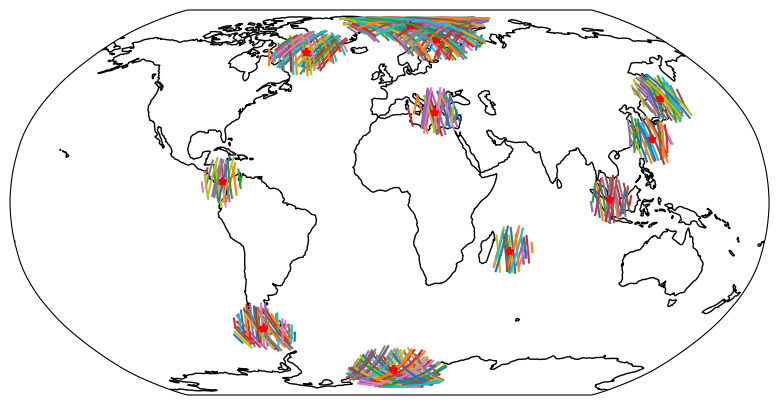

In [12]:
# comm_opportunities_by_sat

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

ground_station_dict = {gs.name: gs for gs in ground_stations}

for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
    for (ground_station, satpass) in sat_passes_with_gs:
        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
        # ax.coastlines()
    
        # request location
        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
        # ground_station = ground_station_dict[gs]
        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    
        # Where is the satellite?
    
        _dt = dt.timedelta(seconds=stride_s)
        time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
    
        _orbit = satellites[satellite]
        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
        axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    
        # Where is the satellite looking?
        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
        # axglobal.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # ax.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # request_counter += 1

In [13]:
ground_stations

[Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
 Location KSAT Nuuk | Lon -51.73363°, lat 64.182789°, alt 0 km,
 Location KSAT Troll | Lon 2.53219°, lat -72.01243°, alt 0 km,
 Location KSAT Hokkaido | Lon 142.3689°, lat 43.8°, alt 0 km,
 Location KSAT Singapore | Lon 103.9915°, lat 1.3661°, alt 0 km,
 Location KSAT Punta Arenas | Lon -70.85021°, lat -52.93279°, alt 0 km,
 Location KSAT Okinawa | Lon 127.7766°, lat 26.4055°, alt 0 km,
 Location KSAT Mauritius | Lon 57.5565°, lat -20.1142°, alt 0 km,
 Location KSAT Nemea | Lon 22.62216°, lat 37.84604°, alt 0 km,
 Location KSAT Vardo | Lon 31.12509°, lat 70.36779°, alt 0 km,
 Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km]

In [14]:
# yam3.get_position(now)
# yam3.get_lonlatalt(now)
# yam3.get_next_passes(now,12,-118,33,0,60,0)

In [15]:
# The first thing you do with a new batch of satellites: plot ground tracks. The simple way.



time_steps_for_plotting = [dt.datetime.now(dt.timezone.utc).replace(tzinfo=None) + dt.timedelta(seconds=stride_s*i) for i in range(int(plot_range_s/stride_s))]

llas = {}
for satellite, orbit in satellites.items():
    llas[satellite] = [orbit.get_lonlatalt(t) for t in time_steps_for_plotting]


In [16]:
# map = Basemap(projection='robin',lon_0=0,resolution='c')
# map.drawcoastlines()

# for satellite in llas:
#     map.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]], '.', latlon=True)

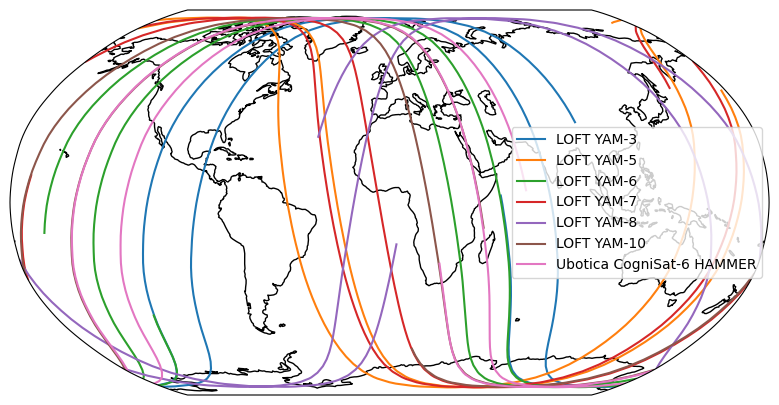

In [17]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for satellite in llas:
    ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
ax.legend()

In [18]:
jpl_lla = [-118.1730155, 34.2009478, 0.329]
passes_horizon_h = 12
passes_error_s = 60
passes_horizon_deg = 0.

passes = {}

for satellite, orbit in satellites.items():
    passes[satellite] = orbit.get_next_passes(dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),passes_horizon_h,jpl_lla[0],jpl_lla[1],jpl_lla[2],passes_error_s,passes_horizon_deg)

In [19]:
for satellite, passlist in passes.items():
    if len(passlist):
        print("{} passes for {}".format(len(passlist), satellite))
        for satpass in passlist:
            print("Start: {}. End: {}. Max altitude: {}".format(satpass[0], satpass[1], satpass[2]))
    else:
        print("No passes for {}".format(satellite))

2 passes for LOFT YAM-3
Start: 2025-10-11 00:11:16.874907. End: 2025-10-11 00:21:03.199734. Max altitude: 2025-10-11 00:16:12.224742
Start: 2025-10-11 01:43:54.906749. End: 2025-10-11 01:53:14.994500. Max altitude: 2025-10-11 01:48:34.773709
2 passes for LOFT YAM-5
Start: 2025-10-11 04:00:14.499129. End: 2025-10-11 04:09:22.381428. Max altitude: 2025-10-11 04:04:47.347808
Start: 2025-10-11 05:32:20.037251. End: 2025-10-11 05:42:57.744310. Max altitude: 2025-10-11 05:37:34.924721
3 passes for LOFT YAM-6
Start: 2025-10-10 23:20:16.451546. End: 2025-10-10 23:29:58.117694. Max altitude: 2025-10-10 23:25:08.021406
Start: 2025-10-11 08:19:56.043936. End: 2025-10-11 08:26:07.984104. Max altitude: 2025-10-11 08:23:02.203003
Start: 2025-10-11 09:50:02.632754. End: 2025-10-11 10:01:03.348036. Max altitude: 2025-10-11 09:55:25.576561
2 passes for LOFT YAM-7
Start: 2025-10-11 05:25:33.126255. End: 2025-10-11 05:35:43.429526. Max altitude: 2025-10-11 05:30:36.755953
Start: 2025-10-11 06:58:53.25626

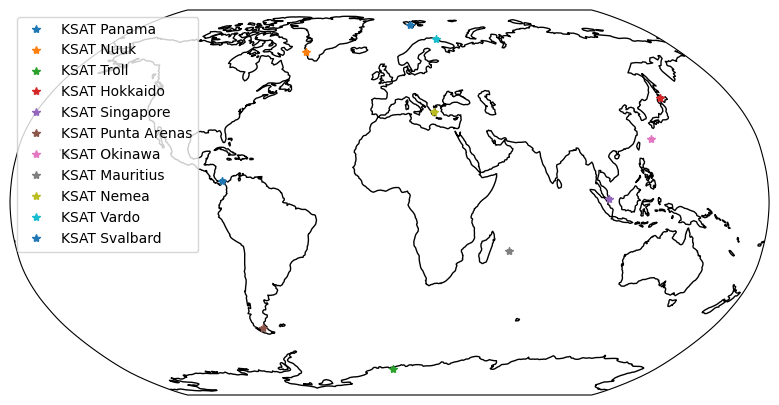

In [20]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for station in ground_stations:
    ax.plot(station.lon_deg, station.lat_deg,'*',transform=ccrs.Geodetic(), label=station.name)
ax.legend()

In [21]:
print(get_elevation_usgs(-118,34))
print(get_elevation_from_open_elevation(-118,34))

295.55368042
307.0


In [22]:
min_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time = min_time + dt.timedelta(hours=24)

os = observation_request(-118,34, alt_km=0.307, min_time=min_time, max_time=max_time)

In [23]:
obs_requests = [
    observation_request(-118., 34., min_time=min_time, max_time=max_time, alt_km=0.307),
    observation_request(8., 45., min_time=min_time, max_time=max_time, alt_km=0.216),
    observation_request(-80., 34., min_time=min_time, max_time=max_time, alt_km=0.041),
]

In [24]:
observation_opportunities = find_observation_opportunities(obs_requests, satellites)

In [25]:
# for request, passes in observation_opportunities.items():
#     for satellite, satpasses in passes.items():
#         for satpass in satpasses:
#             print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))

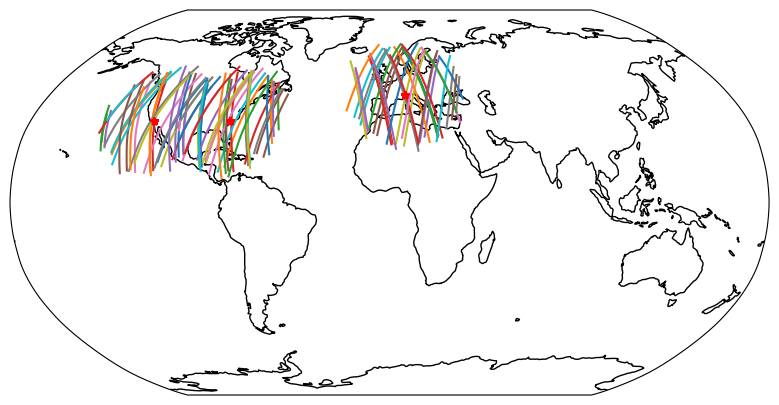

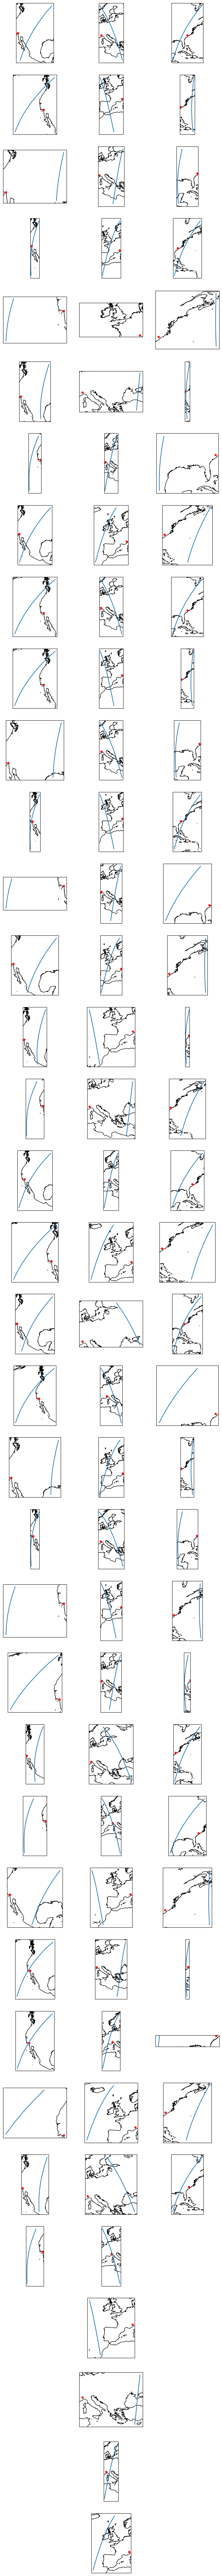

In [26]:
_plot_offset_deg = 20

request_counter = 1
pass_counter = 0

request_number = len(observation_opportunities)
max_num_passes = max([sum([len(passes) for passes in all_passes.values()]) for all_passes in observation_opportunities.values()])

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3*max_num_passes))

for orequest, all_passes in observation_opportunities.items():
    pass_counter = 0
    for satellite, passes in all_passes.items():
        for satpass in passes:
            ax = fig.add_subplot(max_num_passes, request_number, request_counter + request_number*pass_counter, projection=ccrs.Robinson())
            pass_counter += 1
            # ax.set_global()
            # ax.set_extent((float(orequest.lon_deg)-_plot_offset_deg, float(orequest.lon_deg)+_plot_offset_deg, float(orequest.lat_deg)-_plot_offset_deg, float(orequest.lat_deg)+_plot_offset_deg))
            ax.coastlines()
        
            # request location
            ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

            # Where is the satellite?

            _dt = dt.timedelta(seconds=stride_s)
            time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

            # for satellite, orbit in satellites.items():
            _orbit = satellites[satellite]
            _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
            ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
            axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

## Pick the best request. Greeedy, no conflicts or anything

In [27]:
best_request = {r: None for r in obs_requests}

for request, passes in observation_opportunities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request[request] = (_best_satellite, _best_pass)

In [28]:
best_request

{Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129: ('LOFT YAM-5',
  Pass start: 2025-10-11 05:32:17.178756, highest: 2025-10-11 05:37:31.842392, fall: 2025-10-11 05:42:53.746734),
 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129: ('LOFT YAM-7',
  Pass start: 2025-10-11 21:11:07.768999, highest: 2025-10-11 21:16:34.162984, fall: 2025-10-11 21:22:08.894737),
 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129: ('LOFT YAM-7',
  Pass start: 2025-10-11 03:49:52.236192, highest: 2025-10-11 03:55:24.996360, fall: 2025-10-11 04:01:04.313942)}

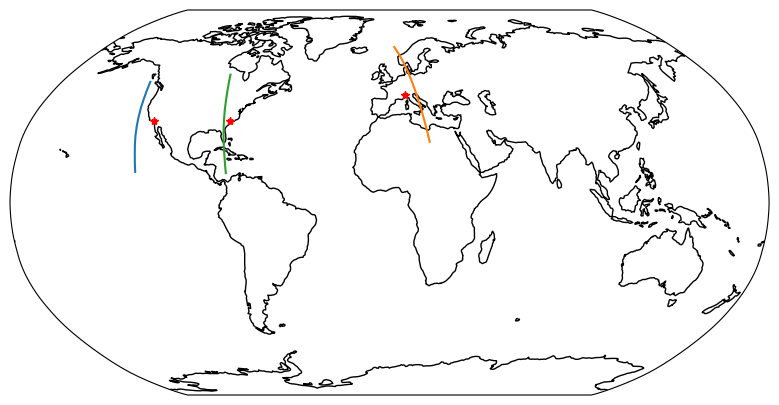

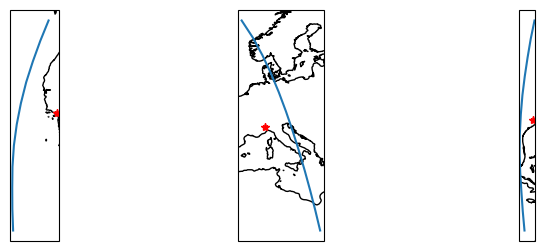

In [29]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3))

for orequest, (satellite, satpass) in best_request.items():
    ax = fig.add_subplot(1, request_number, request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    # for satellite, orbit in satellites.items():
    _orbit = satellites[satellite]
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

For a given set of requests:
- [X] List all the requests. This is what the "most-likely-won't-get-the-observation" policy should request;
- [X] Compute sun angle, view angle, range (for a quality metric)
- [X] Pick the best observation for every opportunity
- [ ] Identify conflicts between observations (slewing time)
- [ ] Pick the best observation for every opportunity with a ILP accounting for conflicts. This is the "I-will-get-every-request" solution.
- [ ] Formulate a MDP with states, actions, transitions, etc.

# More locations

Read a DB of world cities. Generate a good number of locations.

In [30]:
world_cities = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

In [31]:
sampled_world_cities = world_cities.sample(n=100,weights='population',axis=0, random_state=0)

In [32]:
one_hundred_sampled_cities = [
    observation_request(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities.iterrows()
]

In [33]:
# one_hundred_sampled_cities

In [34]:
observation_opportunities_cities = find_observation_opportunities(one_hundred_sampled_cities, satellites)

In [35]:
best_request_cities = {r: None for r in one_hundred_sampled_cities}

for request, passes in observation_opportunities_cities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request_cities[request] = (_best_satellite, _best_pass)

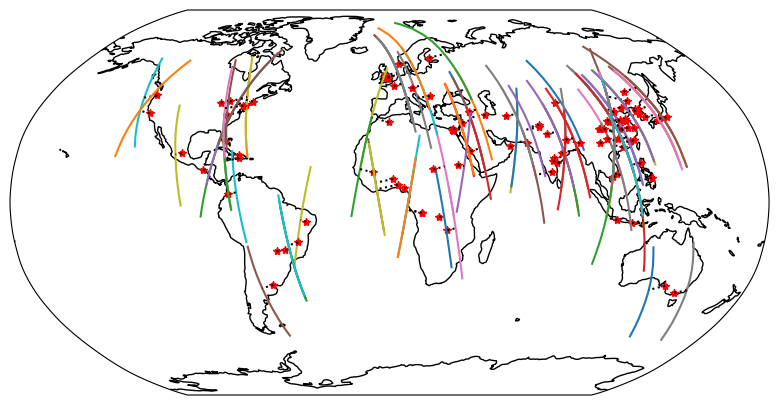

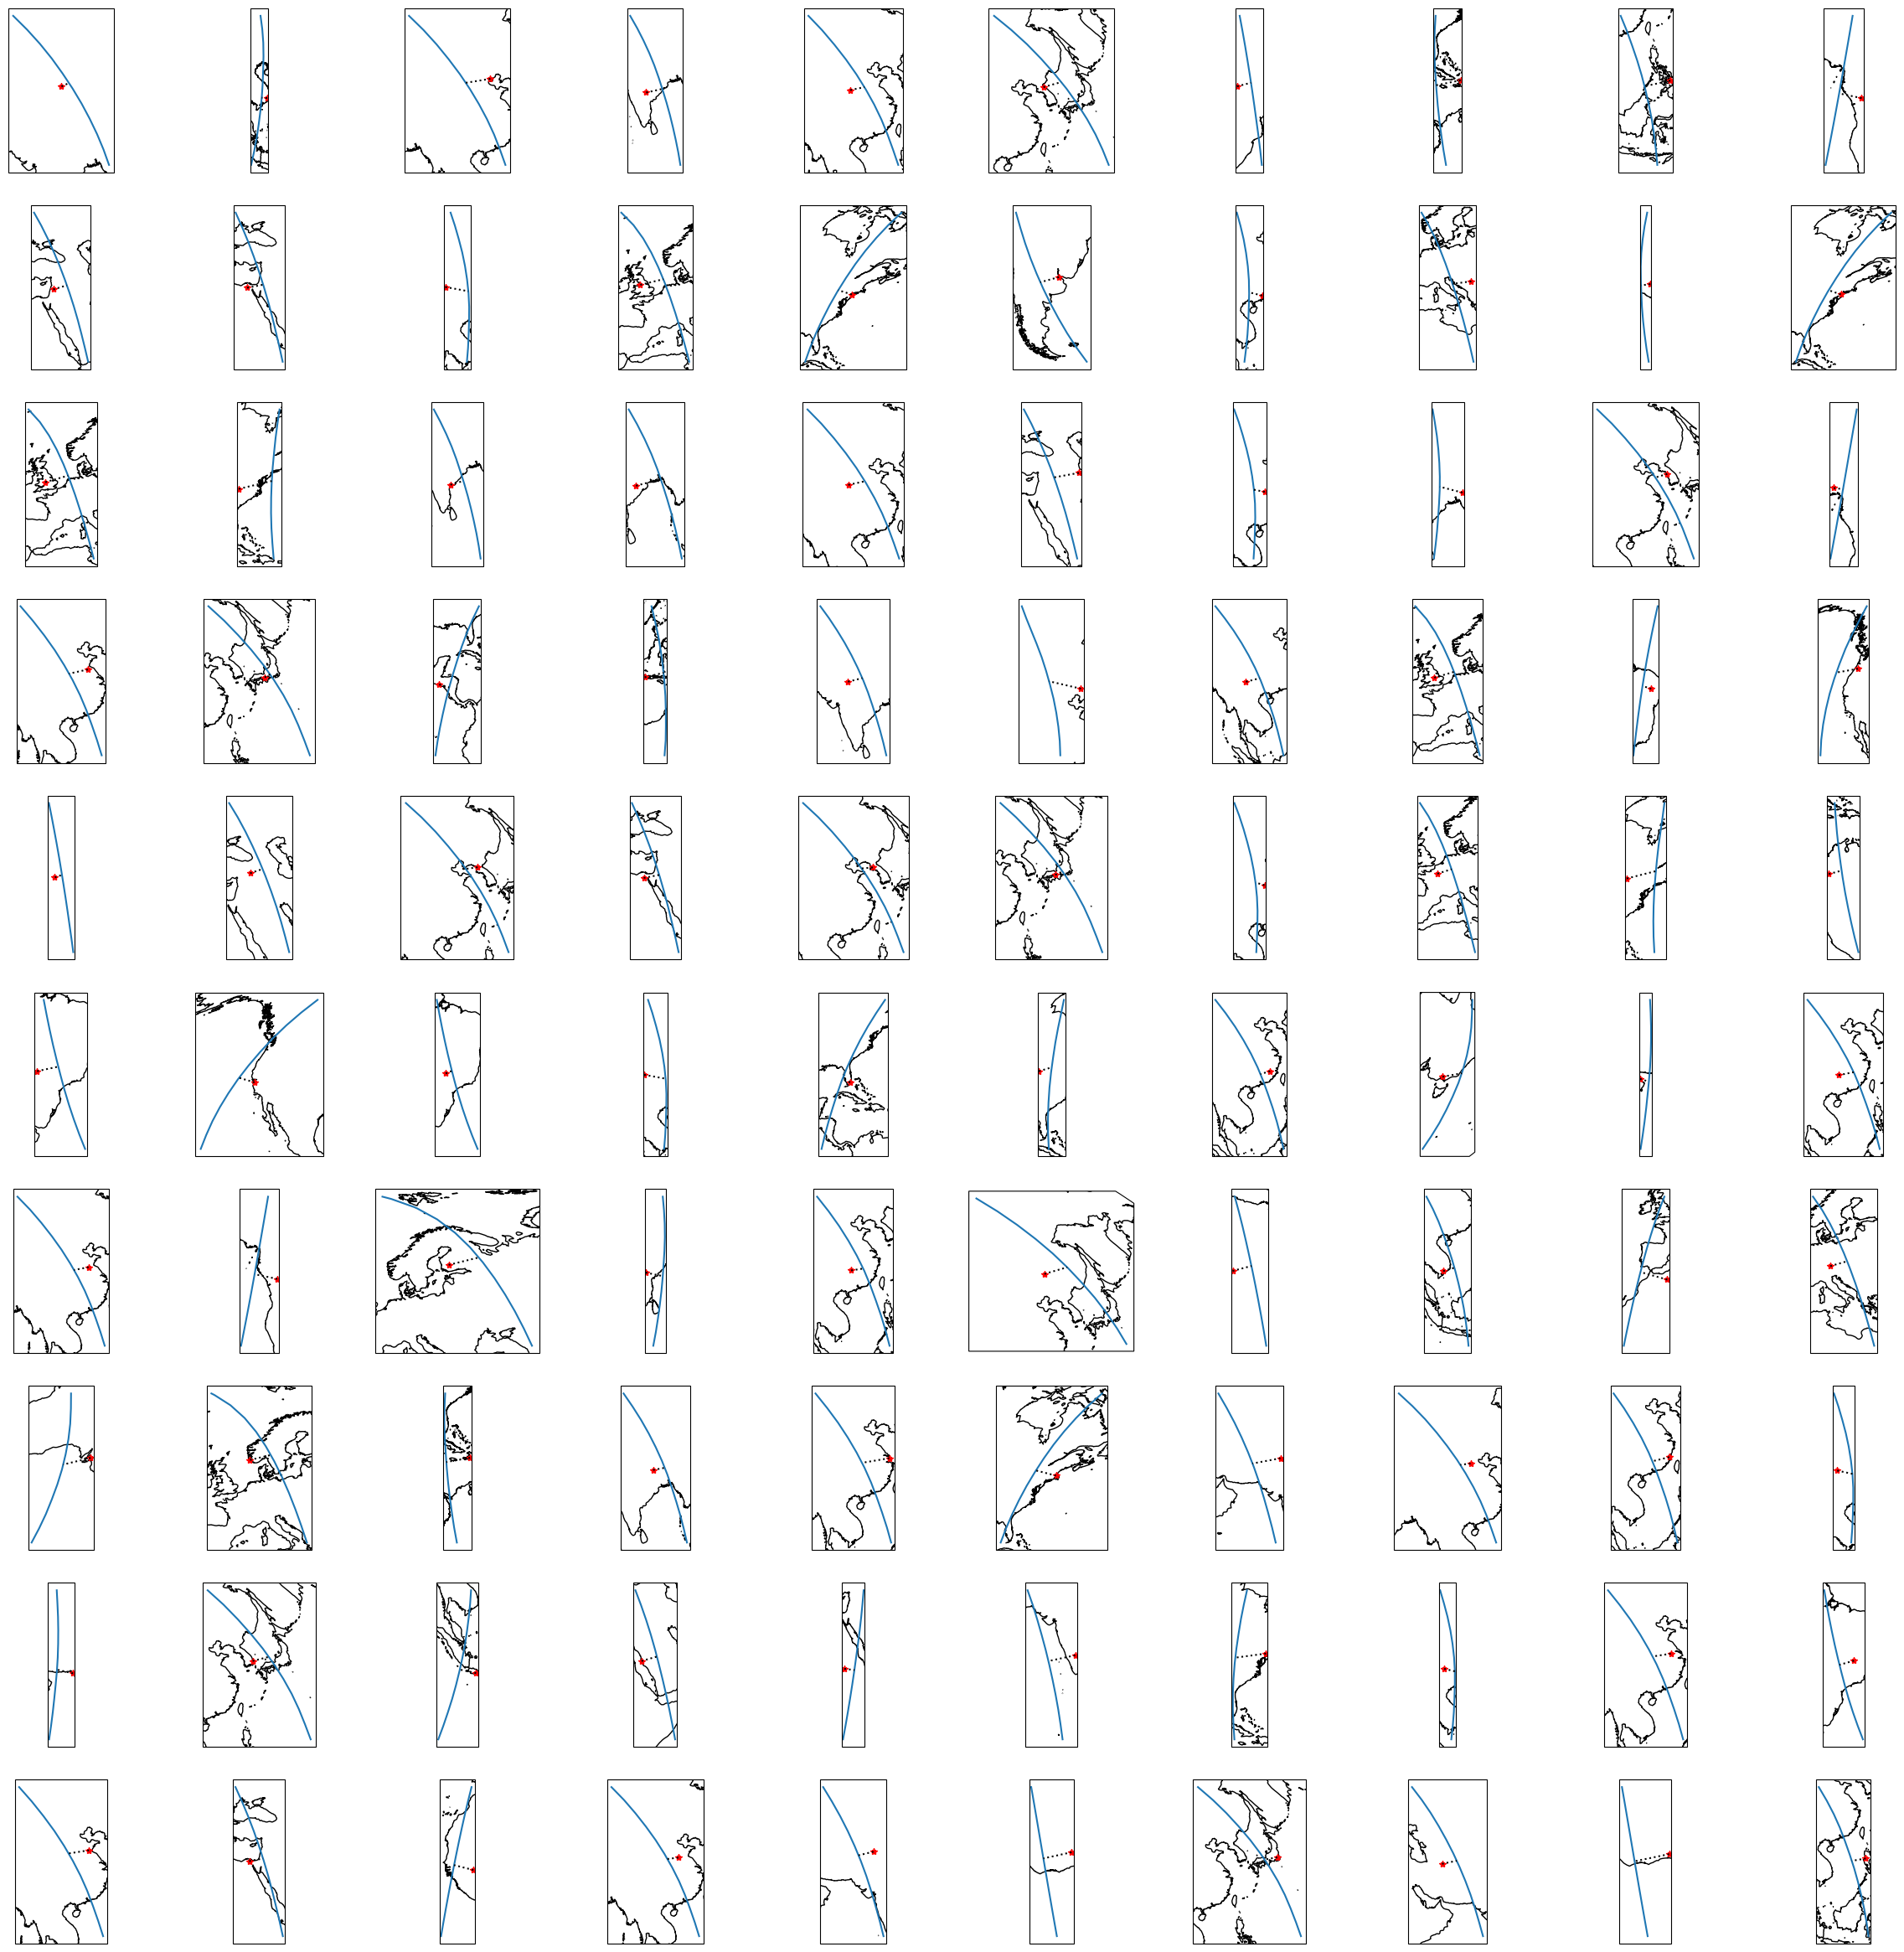

In [36]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities_cities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for orequest, (satellite, satpass) in best_request_cities.items():
    ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    _orbit = satellites[satellite]
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

    # Where is the satellite looking?
    _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
    axglobal.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    ax.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    
    request_counter += 1

# Simulation

Let's talk about simulation.

We want an event-based sim. There is a global ordered timeline and the sim jumps from event to event.

Continuous transitions (power, thermal, etc) are discretized in this setting.

We need a few entities here.

Agent: a satellite, a constellation manager, a requestor. 

Event: something on the ground turning on or off.

Communication: something that affects the state of two entities.

Observation: a query of an agent to (event, empty set). If we want to be fancy, a query of an agent to a region, where events are or are 
not associated with regions.

Prototype:
- A Satellite class with a list of Observations
- A ConstellationManager class with a list of Satellites which can query Observations and add new ones.
  - A ConstellationManager class that updates the Satellites' Observations when a Communication event occurs.
- An Observation of a Region.
    - Observe. Returns an image of the region.
    - Search. Returns True if there is an Event in the Region. The event is stored.
    - Monitor. Returns True if the event is still active.
    - Something for moving events?
- Phenomenon: something with a spatial position, start time, end time, potentially internal states.

The simulator holds:
- Agents (Satellites, ConstellationManagers)
- Phenomena.
- A list of Events (Observation, Communication, Phenomenon transitions), encoded as functions.
The output of the functions affects the agents and phenomena.

We need to define:

- An Observation Opportunity (observation_opportunity)
- An Observer, which has an Orbit, a list of Observation Opportunities to execute, a list of ObservedEvents it has observed (with their state), and a list of DataProducts.
- A ConstellationManager, which has a list of ObserverStates (Orbit, ObservationOpportunities) and a list of CommunicationOpportunities with Observers. When there is a CommunicationOpportunity the ConstellationManager can push an updated list of ObservationOpportunities.
- An Event, with a lonlatalt, a State (enum), and times for StateTransitions.
- 

In [37]:
MIN_HORIZON_ANGLE_FOR_PASS_DEG = 15
MIN_HORIZON_ANGLE_FOR_OBS_DEG = 15

class Event():
    def __init__(self, time: dt.datetime, action_callable, name: str="", id: str=None):
        self.time = time
        self.action_callable = action_callable
        self.name = name
        if id is None:
            id = uuid.uuid4()
        self.id = id
    def __str__(self):
        return "Event {} at {}".format(self.name, self.time)
    def __repr__(self):
        return self.__str__()

class Satellite():
    def __init__(self, name: str,  orbit: Orbital, instrument_fov_rad: float=15.*np.pi/180.):
        self.name = name
        self.orbit = orbit
        self.scheduled_observations = []
        self.data_products = []
        self.known_phenomena = []
        self.instrument_fov_rad = instrument_fov_rad

class Phenomenon(Location):
    def __init__(self, lon_deg: float, lat_deg: float, alt_km: float, start_time: dt.datetime, end_time: dt.datetime, name: str=""):
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=name)
        # self.lon_deg = lon_deg
        # self.lat_deg = lat_deg
        # self.alt_km = alt_km
        self.start_time = start_time
        self.end_time = end_time
        # self.name = name
    def __str__(self):
        return "{}: Lon {}, lat {}, alt {}, start {}, end {}".format(self.name, self.lon_deg,self.lat_deg,self.alt_km, self.start_time, self.end_time)
    def __repr__(self):
        return self.__str__()

   
class World():
    def __init__(self, agents: list=[], phenomena: list = [], events: list = []):
        self.agents = agents
        self.phenomena = phenomena
        self.events = events
        self.time = dt.datetime.min
    
    def tick(self):
        if len(self.events):
            _event = self.events.pop(0)
            print("Executing event {}".format(_event))
            outcome = _event.action_callable()
            self.time = _event.time
            
        else:
            print("No more events")
            pass
        return len(self.events)

    def add_agent(self, agent):
        self.agents.append(agent)
    
    def add_event(self, event):
        # print("Adding {}".format(event))
        if (event.time<self.time):
            raise ValueError("Event {} is earlier than sim time {}".format(event, self.time)) 
        bisect.insort(self.events, event, key=lambda x: x.time)
        
    def do_observation(self, observation: observation_opportunity, spacecraft: Satellite):
        # Find phenomena close to the observation location in space and at the right time
        # Return a data product and a list of event states
        # print("Obs opp {}".format(observation))
        observed_phenomena = []
        for _phenomenon in self.phenomena:
            if (_phenomenon.start_time <= observation.time and _phenomenon.end_time > observation.time):
                # print("Candidate phenomenon {}".format(_phenomenon))
                
                # Compute phenomenon location on the planet
                _ph_location_ecf = np.array(pyorbital.astronomy.observer_position(observation.time, _phenomenon.lon_deg, _phenomenon.lat_deg, _phenomenon.alt_km)[0][:3])
                        # print(np.array(orbit.get_position(_time, normalize=False)))
                # print("Ph location {}".format(_ph_location_ecf))
                # Compute observation location on the planet
                _obs_location_ecf = np.array(pyorbital.astronomy.observer_position(observation.time, observation.lon_deg, observation.lat_deg, observation.alt_km)[0][:3])
                # print("Obs location {}".format(_obs_location_ecf))
                # Compute SC location
                _sc_location_ecf = np.array(spacecraft.orbit.get_position(observation.time, normalize=False)[0][:3])
                # print("Sc location {}".format(_sc_location_ecf))
                # Compute angle between sc-observation and sc-phenomenon
                _ph_sc_vector = _ph_location_ecf-_sc_location_ecf
                _obs_sc_vector = _obs_location_ecf - _sc_location_ecf
                # print("PhSc {} || ObsSc {}".format(_ph_sc_vector, _obs_sc_vector))
                # print("Dot: {} || N1: {} N2: {}".format(np.dot(_ph_sc_vector,_obs_sc_vector),np.linalg.norm(_ph_sc_vector,2), np.linalg.norm(_obs_sc_vector,2))) 
                # print("Acos: {}, angle: {}".format(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)), np.arccos(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)))))
                _ph_obs_angle_rad = np.arccos(np.clip(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)),-1,1))
                # print("Obs angle (rad) {}".format(_ph_obs_angle_rad))
                # If angle<FOV, return phobservation
                if _ph_obs_angle_rad < spacecraft.instrument_fov_rad:
                    # print("Close enough")
                    observed_phenomena.append(_phenomenon)
                else:
                    # print("Too far")
                    pass
        return observed_phenomena
            

class ConstellationGroundScheduler():
    def __init__(self, satellites: list, ground_stations: list, world: World):
        self.satellites = satellites
        self.ground_stations = ground_stations
        self.world = world

    def schedule_request(self, request: observation_request, current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)):
        # Pick the best satellite to fulfill this. This is where we'll need to be smarter. Or not! Just pick something starting the day after.
        print("Scheduling request {}".format(request))
              
        _opportunities = find_observation_opportunities(
            [request,],
            satellites={s.name: s.orbit for s in self.satellites},
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_OBS_DEG
        )
        if len(_opportunities):
            best_request = None
            for request, passes in _opportunities.items():
                _best_quality = - np.inf
                _best_satellite = None
                _best_pass = None
                for satellite, satpasses in passes.items():
                    for satpass in satpasses:
                        _quality = observation_quality(satpass.highest)
                        if _quality >= _best_quality:
                            _best_quality = _quality
                            _best_satellite = satellite
                            _best_pass = satpass
                        # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
                best_request = (_best_satellite, _best_pass)
            print("Best request: {} with {}".format(_best_pass, _best_satellite))
        else:
            print("No observation opportunities here")
            return -1
            
        # Pick the best contact to tell the satellite. What if the contact is after the request? Whoops.
        _, comm_opportunities = find_contact_opportunities(
            ground_stations=self.ground_stations,
            satellites={s.name: s.orbit for s in self.satellites},
            min_time=current_time,
            max_time=_best_pass.highest.time,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_PASS_DEG,
        )

        if len(comm_opportunities[_best_satellite])==0:
            # No contacts!
            print("No timely contact! Maybe we were too greedy")
            return -2
        
        earliest_comm_opportunity = comm_opportunities[_best_satellite][0][1]
        earliest_comm_opportunity_station = comm_opportunities[_best_satellite][0][0]
        # Now recall that _best_satellite is a string, a satellite name.
        # We need to call the proper sat object here
        _best_sat_object = None
        for sat in self.satellites:
            if sat.name == _best_satellite:
                _best_sat_object = sat
        if (_best_sat_object is None):
            print("ERROR! Something wrong with finding the satellite")
            return -3
        # _best_sat_object = next([sat for sat in self.satellites if sat.name == _best_satellite])
        
        # TODO the constellation scheduled doesn't know about world or satellites
        schedule_observation_uplink(self.world, _best_sat_object, earliest_comm_opportunity, _best_pass.highest, earliest_comm_opportunity_station)
        
        # # Schedule an event where we tell the satellite about this. The event calls schedule_observation
        # TODO 
        # - pick the earliest opportunity
        # - check it's early enough (if not return)
        # - schedule an Event at the comm opportunity time that, when triggered, calls schedule_observation with best_request
        return 0

In [38]:
def schedule_observation(_world, satellite, obs_opportunity):

    # This first bit is quite redundant. What you want is to maintain events for individual agents and then a global copy, right?

    satellite.scheduled_observations.append(observation_opportunity)
    _event = Event(
        name = "Obs, sat {}".format(satellite.name),
        time = obs_opportunity.time,
        # Note the kludge of default inputs to make sure the closure works and we capture the variables at the time of creation
        # action_callable = lambda _opp=_opportunity, _satname=_sat.name: print("{} with {}".format(_opp, _satname)) #_sat.known_phenomena.append(world.do_observation(_opportunity, _sat))
        action_callable = lambda _opp=obs_opportunity, _sate=satellite: _sate.known_phenomena.append(world.do_observation(_opp, _sate))
    )
    _world.add_event(_event)
    
    return 0

def schedule_observation_uplink(_world: World, satellite: Satellite, comm_opportunity: observation_opportunity, obs_opportunity: observation_opportunity, station: Location):
    _event = Event(
        name="Uplink, station {} to sat {}".format(station.name, satellite.name),
        time = comm_opportunity.highest.time,
        action_callable = lambda _w=_world, _s=satellite, _o=obs_opportunity: schedule_observation(_w, _s, _o)
    )
    _world.add_event(_event)

Something simple. 
- [X] Create a world.
- [X] Add satellites to it.
- [X] Add observation opportunities to the satellites manually
- [X] Click until out of events
- [X] Add a better way to add observation opportunities!
- [X] Add a ConstellationScheduler 

In [39]:
phenomena = [
    Phenomenon(
        lon_deg = -118.,
        lat_deg = 34.,
        alt_km=0.307,
        start_time=min_time,
        end_time=max_time,

    ),
    Phenomenon(8., 45.,  alt_km=0.216, start_time=min_time, end_time=max_time),
    Phenomenon(-80., 34., alt_km=0.041, start_time=min_time, end_time=max_time),
]

In [40]:
phenomena_cities = [
    Phenomenon(
        lon_deg = city.lon_deg,
        lat_deg = city.lat_deg,
        alt_km=city.alt_km,
        start_time=city.min_time,
        end_time=city.max_time,
        name=city.name
    ) for city in one_hundred_sampled_cities
]

In [41]:
one_hundred_sampled_cities[0].min_time

datetime.datetime(2025, 10, 10, 22, 13, 21, 591129)

In [42]:
satellite_agents = [
    Satellite(
        name=_name,
        orbit=_orbit,
        instrument_fov_rad = 10./180.*np.pi
    ) 
    for _name, _orbit in satellites.items()
]

In [43]:
world = World(agents = satellite_agents, phenomena=phenomena)

Manually add observation opportunities

In [44]:
for req, opp in best_request.items():
    for _sat in world.agents:
        if _sat.name == opp[0]:
            _opportunity = opp[1].highest
            print("{} {} {}".format(_sat.name, req, _opportunity))

            schedule_observation(world, _sat, _opportunity)

LOFT YAM-5 Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129 Observation  at 2025-10-11 05:37:31.842392. Look angle 261.96822687458496 | 28.089236208751274 az/dec deg, zenith angle 141.22067822560334 deg, range 908.8506060068938 km
LOFT YAM-7 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129 Observation  at 2025-10-11 21:16:34.162984. Look angle 74.88699827828862 | 41.78310428831196 az/dec deg, zenith angle 134.5085726033798 deg, range 702.7189949477491 km
LOFT YAM-7 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129 Observation  at 2025-10-11 03:55:24.996360. Look angle 256.54263022851455 | 58.65466453517386 az/dec deg, zenith angle 148.45407955114317 deg, range 562.3873799608473 km


In [45]:
retcode = 1
while (retcode !=0):
    print("\nTick!")
    print(world.events)
    # print({sat.name: sat.scheduled_observations for sat in world.agents if len(sat.scheduled_observations)})
    retcode = world.tick()


Tick!
[Event Obs, sat LOFT YAM-7 at 2025-10-11 03:55:24.996360, Event Obs, sat LOFT YAM-5 at 2025-10-11 05:37:31.842392, Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984]
Executing event Event Obs, sat LOFT YAM-7 at 2025-10-11 03:55:24.996360

Tick!
[Event Obs, sat LOFT YAM-5 at 2025-10-11 05:37:31.842392, Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984]
Executing event Event Obs, sat LOFT YAM-5 at 2025-10-11 05:37:31.842392

Tick!
[Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984]
Executing event Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984


In [46]:
[sat.known_phenomena for sat in world.agents]

[[],
 [[: Lon -118.0, lat 34.0, alt 0.307, start 2025-10-10 22:13:21.591129, end 2025-10-11 22:13:21.591129]],
 [],
 [[: Lon -80.0, lat 34.0, alt 0.041, start 2025-10-10 22:13:21.591129, end 2025-10-11 22:13:21.591129],
  [: Lon 8.0, lat 45.0, alt 0.216, start 2025-10-10 22:13:21.591129, end 2025-10-11 22:13:21.591129]],
 [],
 [],
 []]

In [47]:
world_cities = World(agents = satellite_agents, phenomena=phenomena_cities)

In [48]:
for req, opp in best_request_cities.items():
    for _sat in world_cities.agents:
        # Give the event to the right agent
        if _sat.name == opp[0]:
            # The opportunity is the middle of the pass
            _opportunity = opp[1].highest
            # print("{} {} {}".format(_sat.name, req, _opportunity))

            # This is quite redundant. What you want is to maintain events for individual agents and then a global copy, right?
            _sat.scheduled_observations.append(_opportunity)
            _event = Event(
                time = _opportunity.time,
                # The magic is here: we add an event that does an observation and stores the result in the agent's known_phenomena bin
                # Note the kludge of default inputs to make sure the closure works and we capture the variables at the time of creation
                # action_callable = lambda _opp=_opportunity, _satname=_sat.name: print("{} with {}".format(_opp, _satname)) #_sat.known_phenomena.append(world.do_observation(_opportunity, _sat))
                action_callable = lambda _opp=_opportunity, _sate=_sat: _sate.known_phenomena.append(world_cities.do_observation(_opp, _sate))
            )
            world_cities.add_event(_event)

In [49]:
retcode = 1
while (retcode !=0):
    print("Tick!")
    # print(world_cities.events)
    # print({sat.name: sat.scheduled_observations for sat in world.agents if len(sat.scheduled_observations)})
    retcode = world_cities.tick()

Tick!
Executing event Event  at 2025-10-10 22:58:09.508991
Tick!
Executing event Event  at 2025-10-10 23:04:38.879415
Tick!
Executing event Event  at 2025-10-10 23:05:03.106980
Tick!
Executing event Event  at 2025-10-10 23:05:45.595680
Tick!
Executing event Event  at 2025-10-10 23:34:39.810938
Tick!
Executing event Event  at 2025-10-10 23:40:26.045195
Tick!
Executing event Event  at 2025-10-10 23:53:31.255755
Tick!
Executing event Event  at 2025-10-10 23:53:35.560328
Tick!
Executing event Event  at 2025-10-10 23:53:43.804087
Tick!
Executing event Event  at 2025-10-11 00:19:13.634451
Tick!
Executing event Event  at 2025-10-11 00:25:59.350243
Tick!
Executing event Event  at 2025-10-11 00:34:59.404996
Tick!
Executing event Event  at 2025-10-11 00:37:50.445489
Tick!
Executing event Event  at 2025-10-11 01:21:36.199243
Tick!
Executing event Event  at 2025-10-11 01:32:03.603662
Tick!
Executing event Event  at 2025-10-11 01:33:08.887862
Tick!
Executing event Event  at 2025-10-11 01:33:10.1505

In [50]:
satellite_agents = [
    Satellite(
        name=_name,
        orbit=_orbit,
        instrument_fov_rad = 10./180.*np.pi
    ) 
    for _name, _orbit in satellites.items()
]

world_with_scheduler = World(agents = satellite_agents, phenomena=phenomena)

scheduler = ConstellationGroundScheduler(satellites=satellite_agents, ground_stations=ground_stations, world=world_with_scheduler)

In [51]:
for request in obs_requests:
    scheduler.schedule_request(request=request, current_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None))

Scheduling request Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129
Best request: Pass start: 2025-10-11 05:35:18.236609, highest: 2025-10-11 05:37:31.842392, fall: 2025-10-11 05:39:49.407881 with LOFT YAM-5
Scheduling request Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129
Best request: Pass start: 2025-10-11 21:13:57.441101, highest: 2025-10-11 21:16:34.162984, fall: 2025-10-11 21:19:17.682352 with LOFT YAM-7
Scheduling request Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129
Best request: Pass start: 2025-10-11 03:52:37.603984, highest: 2025-10-11 03:55:24.996360, fall: 2025-10-11 03:58:17.442826 with LOFT YAM-7


In [52]:
obs_requests

[Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129,
 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129,
 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-10-10 22:13:21.591129 to 2025-10-11 22:13:21.591129]

In [53]:
retcode = 1
while (retcode !=0):
    print("Tick!")
    retcode = world_with_scheduler.tick()
    print(world_with_scheduler.events)

Tick!
Executing event Event Uplink, station KSAT Troll to sat LOFT YAM-7 at 2025-10-10 22:44:45.312651
[Event Uplink, station KSAT Troll to sat LOFT YAM-7 at 2025-10-10 22:44:45.548669, Event Uplink, station KSAT Troll to sat LOFT YAM-5 at 2025-10-10 22:53:39.463814, Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984]
Tick!
Executing event Event Uplink, station KSAT Troll to sat LOFT YAM-7 at 2025-10-10 22:44:45.548669
[Event Uplink, station KSAT Troll to sat LOFT YAM-5 at 2025-10-10 22:53:39.463814, Event Obs, sat LOFT YAM-7 at 2025-10-11 03:55:24.996360, Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984]
Tick!
Executing event Event Uplink, station KSAT Troll to sat LOFT YAM-5 at 2025-10-10 22:53:39.463814
[Event Obs, sat LOFT YAM-7 at 2025-10-11 03:55:24.996360, Event Obs, sat LOFT YAM-5 at 2025-10-11 05:37:31.842392, Event Obs, sat LOFT YAM-7 at 2025-10-11 21:16:34.162984]
Tick!
Executing event Event Obs, sat LOFT YAM-7 at 2025-10-11 03:55:24.996360
[Event Obs, sat LOFT Y

Where do we go from here?

The obvious: add conflicts between observations. For now, we can stay in discrete land where an opportunity is an instantaneous thing. Or we can create multiple copies all along the path.
Conflict: two opportunities are on the same satellite and closer than some amount of time. The time should account for (i) some fixed setup (think "wait for the mirror to stop flapping") plus some time related to reorientation.
This misses the fact that one could point the spacecraft slightly away from the target and still get it. 
Can we get that in pre-processing?

Solve the one-off scheduling problem with constraints (greedy, find the best observation that is feasible).

Solve the one-off scheduling problem with constraints including comms (greedy, find the best observation that is feasible after we can talk to a given satellite).

Solve the batch scheduling problem with constraints (ILP? For old times' sake).

Multiple instruments. Spacecraft should have an instrument attached. Requests and S/C have an instrument.

Follow-on requests. A detection causes a follow-up request. Simulate.

Write up the three cases of interest:
- Submit a request and you immediately hear back. Unsubmitting requests is free.
    - Use your favorite black-box scheduling algorithm. Submitting a request==evaluating a constraint.
- Submit a request and you immediately hear back. Unsubmitting requests is expensive.
    - Use your favorite non-backtracking scheduling algorithm. Once you choose, no regrets.
- Submit a request and you don't hear back. This is a DMU problem.
    - State:
    - Actions: schedule an observation on a satellite.
    - Transitions: from "unscheduled" to "scheduled" to "executed" or "rejected" for every observation. 
    - Observations: when a file is downloaded, we find out.
    - Rewards: k if we get an observation, 0 otherwise.